Figure S2: Number of credible sets mapped per PC phenotype (pcQTL) and expression phenotype (eQTL). Dotted red line shows L=10, the maximum number of credible sets possible with SuSiE as run. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from tqdm.auto import tqdm 
tqdm.pandas()

import yaml
config_path= '/home/klawren/oak/pcqtls/config_old/main_pcqtl.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

import sys
sys.path.append('/home/klawren/oak/pcqtls/workflow/scripts')
from utils import *

%config InlineBackend.figure_formats = ['png']
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
plt.rcParams.update({'font.size': 7})

# Define colors for eQTL vs pcQTL
qtl_colors = {'eQTL': '#6FA287', 'pcQTL': '#620059'}

In [21]:
# load in credible sets
print("Loading SuSiE results...")
susie = load_across_tissues(config, load_susie)
susie['cs_id'] = susie['phenotype_id'] + '_cs_' + susie['cs_id'].astype(str)
credible_set_counts = susie.groupby(['phenotype_id', 'tissue_id', 'cluster_id'])['cs_id'].nunique().rename('num_credible_sets').reset_index()

# load in clusters, to get full list of eGene and pcGenes
print("Loading clusters...")
clusters = load_across_tissues(config, load_cluster)

clusters['egene'] = clusters['cluster_id'].str.split('_')
eqtl_phenotypes = clusters.explode('egene')[['cluster_id', 'egene', 'tissue_id']]
eqtl_phenotypes['phenotype_id'] = eqtl_phenotypes['cluster_id'] + '_e_' + eqtl_phenotypes['egene']

clusters['pc_num'] = clusters['egene'].apply(lambda x: list(range(1, len(x)+1)))
pcqtl_phenotypes = clusters.explode('pc_num')[['cluster_id', 'pc_num', 'tissue_id']]
pcqtl_phenotypes['phenotype_id'] = pcqtl_phenotypes['cluster_id'] + '_pc' + pcqtl_phenotypes['pc_num'].astype(str)

# combine credible set counts with phenotypes
eqtl_phenotypes = pd.merge(eqtl_phenotypes, credible_set_counts, on=['tissue_id', 'phenotype_id', 'cluster_id'], how='left')
pcqtl_phenotypes = pd.merge(pcqtl_phenotypes, credible_set_counts, on=['tissue_id', 'phenotype_id', 'cluster_id'], how='left')
eqtl_phenotypes.fillna(0, inplace=True)
pcqtl_phenotypes.fillna(0, inplace=True)

# combine eQTL and pcQTL phenotypes
num_cs_per_phenotype = pd.concat([eqtl_phenotypes, pcqtl_phenotypes], keys=['eQTL', 'pcQTL'], names=['qtl_type']).reset_index()

Loading SuSiE results...
Loading clusters...


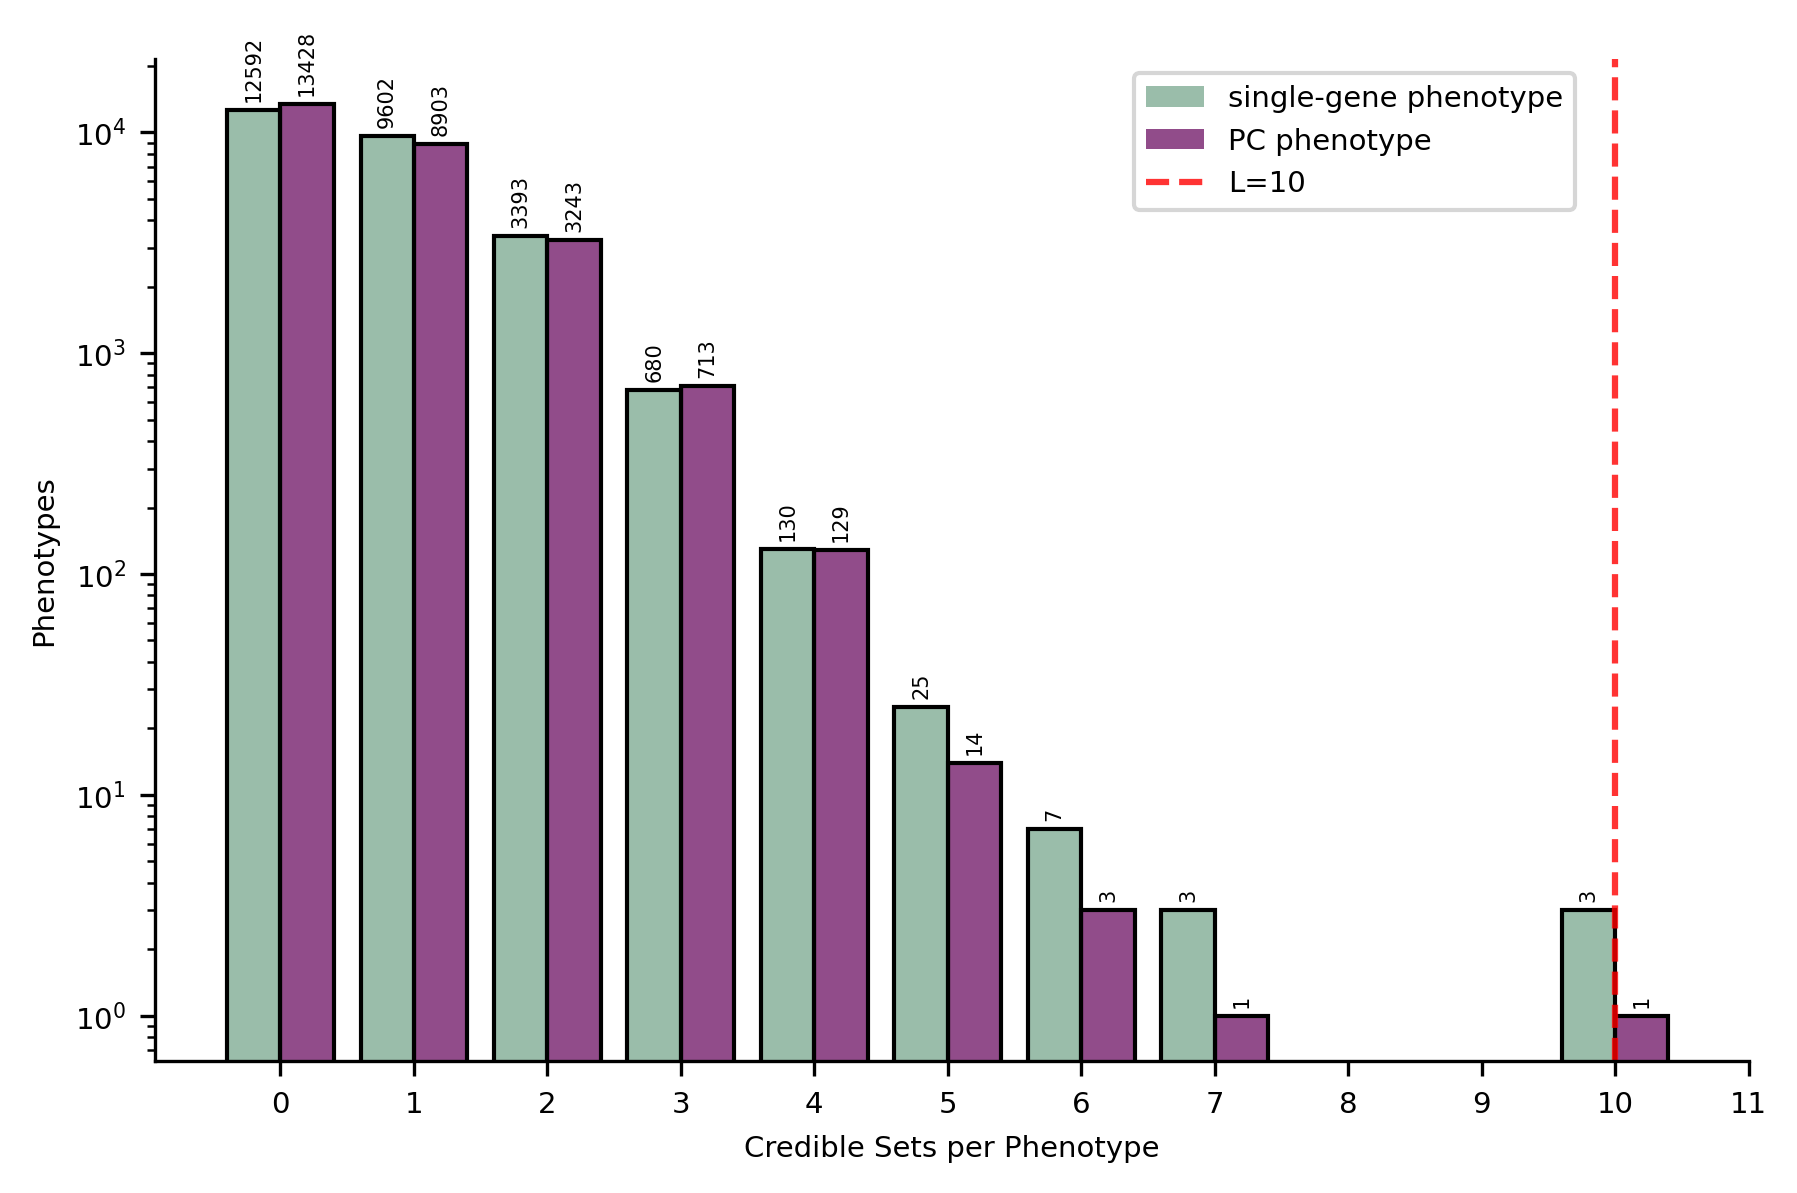

In [36]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# Create histogram using seaborn
sns.histplot(num_cs_per_phenotype, x='num_credible_sets', discrete=True, hue='qtl_type', 
             palette=qtl_colors, alpha=0.7, ax=ax, multiple='dodge', shrink=0.8)

# Set y-axis to log scale
ax.set_yscale('log')

# Add annotations to the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=5, rotation=90, padding=2)

ax.set_xticks(range(0, 12))

ax.set_xlabel('Credible Sets per Phenotype')
ax.set_ylabel('Phenotypes')
ax.spines[['top', 'right']].set_visible(False)

# Add vertical line at L=10
ax.axvline(x=10, color='red', linestyle='--', alpha=0.8, label='L=10 (SuSiE default)')

legend_elements = [
    Patch(facecolor=qtl_colors['eQTL'], alpha=0.7, label='single-gene phenotype'),
    Patch(facecolor=qtl_colors['pcQTL'], alpha=0.7, label='PC phenotype'),
    Line2D([0], [0], color='red', linestyle='--', alpha=0.8, label='L=10')
]
ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(.9, 1))

plt.tight_layout()
plt.savefig('/home/klawren/oak/pcqtls/workflow/supplemental_figures/figures/figure_s2.pdf', 
            transparent=True, bbox_inches='tight')
plt.show()

In [31]:
eqtl_total = len(num_cs_per_phenotype[num_cs_per_phenotype['qtl_type'] == 'eQTL'])
pcqtl_total = len(num_cs_per_phenotype[num_cs_per_phenotype['qtl_type'] == 'pcQTL'])

eqtl_no_cs = len(num_cs_per_phenotype[(num_cs_per_phenotype['qtl_type'] == 'eQTL') & (num_cs_per_phenotype['num_credible_sets'] == 0)])
pcqtl_no_cs = len(num_cs_per_phenotype[(num_cs_per_phenotype['qtl_type'] == 'pcQTL') & (num_cs_per_phenotype['num_credible_sets'] == 0)])

print("{}/{} ({:.2f}%) eqtl phenotypes do not have any credible sets".format(
    eqtl_no_cs, eqtl_total, eqtl_no_cs / eqtl_total * 100 if eqtl_total > 0 else 0))
print("{}/{} ({:.2f}%) pcqtl phenotypes do not have any credible sets".format(
    pcqtl_no_cs, pcqtl_total, pcqtl_no_cs / pcqtl_total * 100 if pcqtl_total > 0 else 0))
print("{} ({:.2f}%) phenotypes have more than 9 credible sets".format(len(num_cs_per_phenotype[num_cs_per_phenotype['num_credible_sets'] > 9]), 
    len(num_cs_per_phenotype[num_cs_per_phenotype['num_credible_sets'] > 9])/len(num_cs_per_phenotype)*100))

12592/26435 (47.63%) eqtl phenotypes do not have any credible sets
13428/26435 (50.80%) pcqtl phenotypes do not have any credible sets
4 (0.01%) phenotypes have more than 9 credible sets
